# Notebook 2 - Building the label

Turns the delivery dates in `01_ml_table.parquet` into a target, and writes
`artifacts/02_labeled.parquet`.

The label cannot be repaired later: if it is wrong, the split, the features and the model all
measure the wrong thing. So it gets interrogated before it is built - who is eligible for a label,
whether the timestamps behind it hold up, what "late" means exactly, and how imbalanced the result
is.

## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

ARTIFACTS = Path("..") / "artifacts"

ml = pd.read_parquet(ARTIFACTS / "01_ml_table.parquet")
print(f"Read: {len(ml):,} rows x {ml.shape[1]} columns")
ml[["order_id", "order_status", "order_purchase_timestamp",
    "order_estimated_delivery_date", "order_delivered_customer_date"]].head()

Read: 99,441 rows x 37 columns


,order_id,order_status,order_purchase_timestamp,order_estimated_delivery_date,order_delivered_customer_date
0,e481f51cbdc54678b7cc49136f2d6af7,delivered,2017-10-02 10:56:33,2017-10-18,2017-10-10 21:25:13
1,47770eb9100c2d0c44946d9cf07ec65d,delivered,2018-08-08 08:38:49,2018-09-04,2018-08-17 18:06:29
2,949d5b44dbf5de918fe9c16f97b45f8a,delivered,2017-11-18 19:28:06,2017-12-15,2017-12-02 00:28:42
3,6514b8ad8028c9f2cc2374ded245783f,delivered,2017-05-16 13:10:30,2017-06-07,2017-05-26 12:55:51
4,76c6e866289321a7c93b82b54852dc33,delivered,2017-01-23 18:29:09,2017-03-06,2017-02-02 14:08:10


## 1. Who is eligible for a label

A label needs an actual delivery date. An order that has not been delivered is neither on time nor
late - it is unknown, and putting it in either class pollutes the data.

In [2]:
population = (ml.groupby("order_status")
                .agg(orders=("order_id", "size"),
                     no_delivery_date=("order_delivered_customer_date",
                                       lambda s: s.isna().sum()))
                .sort_values("orders", ascending=False))
population["has_delivery_date"] = population["orders"] - population["no_delivery_date"]
population

,orders,no_delivery_date,has_delivery_date
order_status,,,
delivered,96478,8,96470
shipped,1107,1107,0
canceled,625,619,6
unavailable,609,609,0
invoiced,314,314,0
processing,301,301,0
created,5,5,0
approved,2,2,0


Two edge cases: 8 orders whose status is `delivered` but carry no delivery date, and canceled
orders that do carry one.

In [3]:
canceled_but_delivered = ml[(ml["order_status"] == "canceled")
                            & ml["order_delivered_customer_date"].notna()]

print(f"{len(canceled_but_delivered)} canceled orders that still carry a delivery date")
canceled_but_delivered[["order_id", "order_status", "order_purchase_timestamp",
                        "order_delivered_customer_date",
                        "order_estimated_delivery_date"]]

6 canceled orders that still carry a delivery date


,order_id,order_status,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date
4412,dabf2b0e35b423f94618bf965fcb7514,canceled,2016-10-09 00:56:52,2016-10-16 14:36:59,2016-11-30
29725,8beb59392e21af5eb9547ae1a9938d06,canceled,2016-10-08 20:17:50,2016-10-19 18:47:43,2016-11-30
46309,65d1e226dfaeb8cdc42f665422522d14,canceled,2016-10-03 21:01:41,2016-11-08 10:58:34,2016-11-25
47234,2c45c33d2f9cb8ff8b1c86cc28c11c30,canceled,2016-10-09 15:39:56,2016-11-09 14:53:50,2016-12-08
51220,1950d777989f6a877539f53795b4c3c3,canceled,2018-02-19 19:48:52,2018-03-21 22:03:51,2018-03-09
78873,770d331c84e5b214bd9dc70a10b829d0,canceled,2016-10-07 14:52:30,2016-10-14 15:07:11,2016-11-29


Kept: `order_status == "delivered"` **and** a delivery date present.

The 6 canceled orders are excluded even though they have a date - the question is whether an order
arrives on time, not whether it arrived and was then canceled. The 8 contradictory ones fall out on
their own. Both counts are tiny, but the choice is written down explicitly.

In [4]:
labeled = ml[(ml["order_status"] == "delivered")
             & ml["order_delivered_customer_date"].notna()].copy()

print(f"Population eligible for a label: {len(labeled):,} orders")
print(f"Excluded: {len(ml) - len(labeled):,} orders ({100*(len(ml)-len(labeled))/len(ml):.2f}%)")

Population eligible for a label: 96,470 orders
Excluded: 2,971 orders (2.99%)


## 2. Are the timestamps sound?

The label is built from two columns, so those two columns are checked first. Any timestamp that
breaks the order of events (purchase, approval, handover, delivery) signals a recording fault.

In [5]:
checks = {
    "delivered before purchased":
        (labeled["order_delivered_customer_date"] < labeled["order_purchase_timestamp"]).sum(),
    "delivered to customer before handed to carrier":
        (labeled["order_delivered_customer_date"] < labeled["order_delivered_carrier_date"]).sum(),
    "approved before purchased":
        (labeled["order_approved_at"] < labeled["order_purchase_timestamp"]).sum(),
    "delivered with no carrier handover date":
        (labeled["order_delivered_carrier_date"].isna()).sum(),
}
pd.Series(checks, name="orders").to_frame()

,orders
delivered before purchased,0
delivered to customer before handed to carrier,23
approved before purchased,0
delivered with no carrier handover date,1


## 3. What "late" means - the midnight problem

The obvious definition is

```
is_late = order_delivered_customer_date > order_estimated_delivery_date
```

which assumes the promise is an instant. The checks above found no anomaly in either column, so the
remaining question is what the promised date actually represents.

In [6]:
est = labeled["order_estimated_delivery_date"]
at_midnight = (est.dt.time == pd.Timestamp("00:00:00").time()).sum()

print(f"Promised dates whose time is 00:00:00 : {at_midnight:,} out of {len(est):,}")
print(f"Share: {100*at_midnight/len(est):.2f}%")

Promised dates whose time is 00:00:00 : 96,470 out of 96,470
Share: 100.00%


Every promised date sits at `00:00:00`. That is a missing hour, not a promise to deliver at
midnight - so the promise is a day.

Under `>` an order promised for the 20th and delivered on the 20th at ten in the morning counts as
late. Both definitions are built below and the gap between them measured.

In [7]:
# how many days between the actual delivery and the promised date (negative = arrived early)
labeled["days_late"] = (
    (labeled["order_delivered_customer_date"] - labeled["order_estimated_delivery_date"])
    .dt.total_seconds() / 86400
)

# the literal definition: compare the timestamps exactly as they are
labeled["is_late_ts"] = (labeled["order_delivered_customer_date"]
                         > labeled["order_estimated_delivery_date"])

# the calendar definition: compare day against day - ignore the hour
labeled["is_late_cal"] = (labeled["order_delivered_customer_date"].dt.normalize()
                          > labeled["order_estimated_delivery_date"].dt.normalize())

comparison = pd.DataFrame({
    "definition": ["literal (timestamp)", "calendar (day vs day)"],
    "late": [labeled["is_late_ts"].sum(), labeled["is_late_cal"].sum()],
    "share %": [round(100*labeled["is_late_ts"].mean(), 2),
                round(100*labeled["is_late_cal"].mean(), 2)],
})
comparison

,definition,late,share %
0,literal (timestamp),7826,8.11
1,calendar (day vs day),6534,6.77


### The orders the two definitions disagree on

In [8]:
disputed = labeled[labeled["is_late_ts"] & ~labeled["is_late_cal"]]

print(f"{len(disputed):,} orders on which the two definitions disagree")
print(f"= {100*len(disputed)/labeled['is_late_ts'].sum():.1f}% of the positive class under the literal definition")
print()
print("At what hour of the promised day did these orders arrive?")
print((disputed["order_delivered_customer_date"].dt.hour
       .describe()[["min", "25%", "50%", "75%", "max"]].round(1)).to_string())

1,292 orders on which the two definitions disagree
= 16.5% of the positive class under the literal definition

At what hour of the promised day did these orders arrive?
min     0.0
25%    14.0
50%    18.0
75%    20.0
max    23.0


In [9]:
disputed[["order_id", "order_estimated_delivery_date",
          "order_delivered_customer_date", "days_late"]].head(8)

,order_id,order_estimated_delivery_date,order_delivered_customer_date,days_late
17,8563039e855156e48fccee4d611a3196,2018-03-20,2018-03-20 00:59:25,0.041262
115,c82a457d646f77c8f151e12a3e517ed2,2018-08-15,2018-08-15 15:02:09,0.626493
192,5342acb7b183acec77f59e4d78f7c804,2018-04-24,2018-04-24 16:10:44,0.674120
384,ed24759a0ae96582e88fdca0c0997d22,2018-04-23,2018-04-23 14:57:48,0.623472
387,f98ae4bbfd1a32ea2104c8cf1f64dabf,2018-03-27,2018-03-27 22:06:48,0.921389
559,74016effecaa79d592487f6a4ee47d4b,2017-03-21,2017-03-21 08:37:58,0.359699
600,f4f88d0fded20ff7a60fb80ccdd533d2,2018-08-20,2018-08-20 23:25:22,0.975949
717,eb314576a333adeb296496f38c4c7852,2018-02-16,2018-02-16 01:28:48,0.061667


`is_late` is the calendar definition.

The company promises a date, so an order that arrives on the promised day - even at 11 at night -
is a promise kept. Under the literal rule those 1,292 orders would be 16% of the positive class.

`is_late_ts` stays in the artifact, so switching definitions is a one-line change.

In [10]:
labeled["is_late"] = labeled["is_late_cal"]

# disputed was taken before the column was added, so we re-derive it to carry the new column
disputed = labeled[labeled["is_late_ts"] & ~labeled["is_late_cal"]]

print(f"is_late    (primary, calendar) : {labeled['is_late'].sum():,} late  "
      f"({100*labeled['is_late'].mean():.2f}%)")
print(f"is_late_ts (alternative, literal) : {labeled['is_late_ts'].sum():,} late  "
      f"({100*labeled['is_late_ts'].mean():.2f}%)")

is_late    (primary, calendar) : 6,534 late  (6.77%)
is_late_ts (alternative, literal) : 7,826 late  (8.11%)


## 4. Checking the label by hand

The task asks for the label to be verified on real orders before it is relied on. Below: a sample
of each case, then the label recomputed by an independent route and compared.

In [11]:
def show(title, frame, n=3):
    print(f"\n{'='*70}\n{title}\n{'='*70}")
    view = frame.head(n)[["order_estimated_delivery_date",
                          "order_delivered_customer_date",
                          "days_late", "is_late"]].copy()
    view["days_late"] = view["days_late"].round(2)
    print(view.to_string(index=False))

show("Clearly late (more than 5 days)", labeled[labeled["days_late"] > 5].sample(5, random_state=42))
show("Clearly on time (arrived more than 5 days early)", labeled[labeled["days_late"] < -5].sample(5, random_state=42))
show("Borderline - arrived on the promised day itself", disputed.sample(5, random_state=42))


Clearly late (more than 5 days)
order_estimated_delivery_date order_delivered_customer_date  days_late  is_late
                   2018-08-08           2018-08-13 16:54:31       5.70     True
                   2017-12-15           2018-01-08 22:39:20      24.94     True
                   2017-08-18           2017-08-24 19:37:28       6.82     True



Clearly on time (arrived more than 5 days early)
order_estimated_delivery_date order_delivered_customer_date  days_late  is_late
                   2018-08-01           2018-07-26 22:06:35      -5.08    False
                   2018-05-28           2018-05-18 13:32:23      -9.44    False
                   2018-04-18           2018-04-02 19:03:18     -15.21    False

Borderline - arrived on the promised day itself
order_estimated_delivery_date order_delivered_customer_date  days_late  is_late
                   2018-07-27           2018-07-27 17:38:45       0.74    False
                   2018-08-08           2018-08-08 21:03:25       0.88    False
                   2017-11-23           2017-11-23 22:42:35       0.95    False


In [12]:
# independent check: recompute the label in a completely different way (string comparison of the dates)
# if both ways agree on every single row, the logic is sound
manual = (labeled["order_delivered_customer_date"].dt.strftime("%Y-%m-%d")
          > labeled["order_estimated_delivery_date"].dt.strftime("%Y-%m-%d"))

mismatches = (manual != labeled["is_late"]).sum()
assert mismatches == 0, f"{mismatches} rows do not match - the label logic is wrong"
print(f"OK  both methods agree on all {len(labeled):,} rows - the label is logically correct")

OK  both methods agree on all 96,470 rows - the label is logically correct


### Outliers in `days_late`

In [13]:
d = labeled["days_late"]
print(f"Earliest delivery : {d.min():>8.1f} days before the promise")
print(f"Median            : {d.median():>8.1f} days  (the typical order arrives {abs(d.median()):.0f} days before its promise)")
print(f"Largest delay     : {d.max():>8.1f} days after the promise")

Earliest delivery :   -146.0 days before the promise
Median            :    -11.9 days  (the typical order arrives 12 days before its promise)
Largest delay     :    189.0 days after the promise


The median is about two weeks early. That looks like a large safety buffer in the promise, and lateness still happens anyway - left for notebook 4.

Delivered 146 days early and delayed 189 days are plausible in a market this wide and do not
indicate a broken label.

## 5. Class distribution

In [14]:
counts = labeled["is_late"].value_counts().sort_index()
counts.index = ["on time (0)", "late (1)"]

dist = counts.to_frame("orders")
dist["pct"] = (100 * counts / counts.sum()).round(2)
dist

,orders,pct
on time (0),89936,93.23
late (1),6534,6.77


In [15]:
minority = labeled["is_late"].mean()
ratio = (1 - minority) / minority

print(f"Minority class share : {100*minority:.2f}%")
print(f"Imbalance ratio      : 1 late for every {ratio:.1f} on time")

Minority class share : 6.77%
Imbalance ratio      : 1 late for every 13.8 on time


In [16]:
trivial_accuracy = 1 - minority

print(f"The 'everything is on time' model:")
print(f"  accuracy : {100*trivial_accuracy:.2f}%")
print(f"  recall on late orders : 0.00%")
print(f"  late orders it catches : 0 out of {labeled['is_late'].sum():,}")
print()
print("Any real model that fails to beat this accuracy will look 'worse' while being far more useful.")

The 'everything is on time' model:


  accuracy : 93.23%
  recall on late orders : 0.00%
  late orders it catches : 0 out of 6,534

Any real model that fails to beat this accuracy will look 'worse' while being far more useful.


The imbalance is moderate: ~7% minority, but more than 6,000 positive cases, which is enough to
learn from. The metric and the decision threshold are the problem, not the number of examples.

For notebook 6: PR-AUC first, ROC-AUC alongside it, and recall at a fixed alert budget - if we can
intervene on 5% of orders, how many late ones do we catch. `class_weight="balanced"` or threshold
tuning before any resampling. Accuracy for comparison only.

## 6. Is the label stable over time?

A quality check on the label itself. If the late rate swings
sharply month to month then the base rate itself moves, which changes how the data should be split
and how the result should be measured.

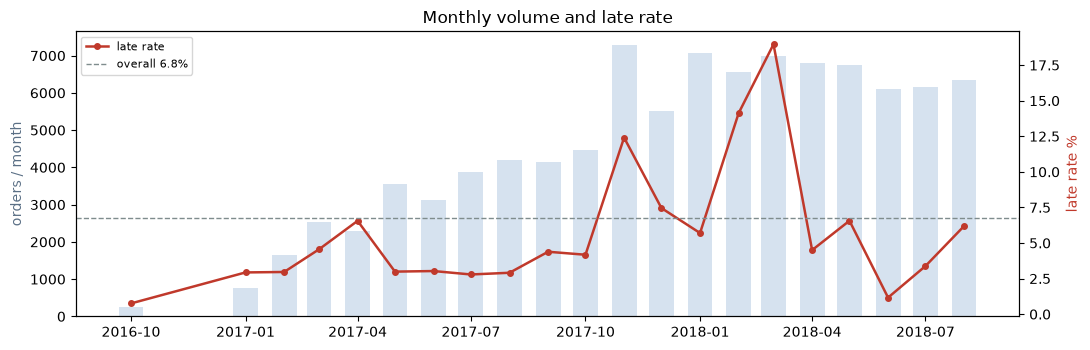

Lowest monthly late rate  : 0.75%
Highest monthly late rate : 18.96%


In [17]:
monthly = (labeled
           .assign(month=labeled["order_purchase_timestamp"].dt.to_period("M").dt.to_timestamp())
           .groupby("month")
           .agg(orders=("order_id", "size"), late_rate=("is_late", "mean")))

# exclude the near-empty months from the plot only (2016 and the very start of activity)
plot_data = monthly[monthly["orders"] >= 100]

fig, ax = plt.subplots(figsize=(11, 3.6))
ax.bar(plot_data.index, plot_data["orders"], width=20, color="#d6e2ef", label="orders")
ax.set_ylabel("orders / month", color="#5b7086")
ax2 = ax.twinx()
ax2.plot(plot_data.index, 100*plot_data["late_rate"], color="#c0392b", marker="o",
         markersize=4, linewidth=1.8, label="late rate")
ax2.axhline(100*minority, color="#7f8c8d", linestyle="--", linewidth=1,
            label=f"overall {100*minority:.1f}%")
ax2.set_ylabel("late rate %", color="#c0392b")
ax.set_title("Monthly volume and late rate")
ax2.legend(loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

print(f"Lowest monthly late rate  : {100*plot_data['late_rate'].min():.2f}%")
print(f"Highest monthly late rate : {100*plot_data['late_rate'].max():.2f}%")

The late rate runs from under 2% to over 20% depending on the month, so the base rate moves.

Two consequences for notebook 3: the split should be chronological, since a random one hands the
model information about the very month it is tested on; and a threshold tuned on validation will
not carry over to test, so ranking metrics are safer than a fixed cut.

## 7. Saving

In [18]:
label_cols = ["is_late", "is_late_ts", "is_late_cal", "days_late"]
print("Label columns added:", label_cols)

out = ARTIFACTS / "02_labeled.parquet"
labeled.to_parquet(out, index=False)

print(f"\nSaved: {out}  ({out.stat().st_size/1024**2:.1f} MB)")
print(f"       {len(labeled):,} rows x {labeled.shape[1]} columns")
print(f"       late rate: {100*labeled['is_late'].mean():.2f}%")

Label columns added: ['is_late', 'is_late_ts', 'is_late_cal', 'days_late']



Saved: ..\artifacts\02_labeled.parquet  (17.6 MB)
       96,470 rows x 41 columns
       late rate: 6.77%


---

**Result:** `artifacts/02_labeled.parquet` - 96,470 delivered orders with the label.

Added columns: `is_late` (primary) - `is_late_ts` - `is_late_cal` - `days_late`.

| Decision | Choice |
|---|---|
| Population | `delivered` and has a delivery date |
| Canceled with a delivery date | excluded |
| Definition of late | calendar day vs day (6.77%) |
| Literal definition | kept in `is_late_ts` (8.11%) |
| Timestamp anomalies | documented, no rows dropped |